# 1.初始化LLM

In [1]:
import os
from langchain_openai import ChatOpenAI   # openai接口
from langchain_ollama import ChatOllama   # ollama接口

In [5]:
# openai接口
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="qwen3.5-plus",             # 模型名称
    openai_api_key="sk-bvOWJIfQ8Y8IrZhzzpQZ80zSKHjWIHCkPXEgQ0H4Li5UCpUC",         # API Key
    openai_api_base="http://ai.wenmodel.com/v1", # API 地址 https://ai.wenmodel.com(https://m.tb.cn/h.ioaPOiq?tk=QGsd5gSbXZ)
    temperature=0.7,
    max_tokens=1024
)

response = llm.invoke("你是谁")
print(response.content)

你好！我是 **Qwen3.5**，阿里巴巴最新推出的通义千问大语言模型。我具备以下核心能力：

- **超长上下文**：支持 256K 上下文窗口，可完整理解数十万字的文档或长视频内容。
- **多语言覆盖**：流畅处理全球 100+ 种语言，包括中文、英语、小语种等。
- **知识时效性**：训练数据截止至 **2026 年**，掌握最新科技、文化及行业动态。
- **深度推理**：在数学、物理、逻辑推理领域全面强化，可拆解复杂问题并给出严谨推导。
- **视觉解析**：不仅能识别图像内容，还能分析图表、公式、科学图示的因果关系。
- **代码全栈**：支持生成、调试、优化代码，甚至将创意直接转化为可运行的前端页面。
- **智能体协作**：可自主规划多步骤任务（如数据检索→分析→可视化），并调用工具链完成闭环。

需要我帮你处理具体任务吗？比如解析一篇论文、生成数据分析报告，或是调试一段代码？ 😊


In [3]:
# ollama接口
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="qwen3.5:0.8b",   # 必须使用支持tool-calling功能模型
    temperature=0.7,
    base_url="http://127.0.0.1:11435"
)

response = llm.invoke("你是谁")
print(response.content)

你好！我是通义千问（Qwen），阿里巴巴集团旗下的通义实验室自主研发的超大规模语言模型。我具备强大的语言和逻辑推理能力、多模态处理以及跨领域知识整合等特性。不过需要注意的是：作为AI助手，我的信息仅限于公开可获取的知识范围内，且所有功能开发均遵循中国法律法规和伦理道德规范。如果需要解决具体问题或探讨相关话题，我很乐意提供帮助！


# 2.构造智能体

## 2.1 构造@tool方法

In [7]:
from langchain.tools import tool

@tool
def get_calculate(expr: str):
    '''
    功能:根据用户输入的字符串表达式进行数学计算。
    Args:
        expr:表达式，例如 "1+1*1"
    return:
        计算的结果
    '''
    result = eval(expr)
    return result

## 2.2 初始化智能体对象

In [45]:
from langchain.agents import create_agent

# 初始化智能体
agent = create_agent(
    model=llm,
    tools=[get_calculate],
    system_prompt="你是一个aiot智能体。"
)


## 2.3 封装调用函数

In [13]:
# 一次请求函数
def chat_invoke(message):
    result = agent.invoke(
        {
            "messages":message
        }, 
    )
    print('响应状态:\n', result)
    print('\n--------------\n')
     
    # 3. 查看消息历史（包含 AI 的工具调用和工具返回结果）
    print("=== 完整消息历史 ===")
    for msg in result["messages"]:
        # system提示词
        if msg.type == "system":
           print(f"[{msg.type}] {msg.content}")  
        
        # user文本内容
        if msg.type == "human":
           print(f"[{msg.type}] {msg.content}")  
        
        # ai文本内容
        if msg.type == "ai":
            print(f"[{msg.type}] {msg.content}") 
            
        # tool工具调用内容
        if msg.type == "tool":
            print(f"[调用工具 {msg.name}]")
            print(f"[{msg.type}] {msg.content}") 


In [10]:
def chat_stream(message):
    result = agent.stream(
        {"messages":message}, 
        stream_mode='updates'
    )

    # token统计
    total_tokens = 0
    total_input_tokens = 0
    total_output_tokens = 0
    
    for chunk in result:
        for node_name, update in chunk.items():
            print('-----------------------------')
            print(f"节点：{node_name}\n", end=" ")
            
            if "messages" in update:
                for msg in update["messages"]:
                    
                    # system提示词
                    if msg.type == "system":
                       print(f"[{msg.type}] {msg.content}")  
                   
                    # user文本内容
                    if msg.type == "human":
                       print(f"[{msg.type}] {msg.content}")  
                    
                    # ai回复
                    if msg.type == "ai":
                        if msg.content:
                            print(f"[{msg.type}] {msg.content}")
                        
                        if hasattr(msg, 'tool_calls') and msg.tool_calls:
                            calls = [tc['name'] for tc in msg.tool_calls]
                            print(f"请求调用: {calls}")
    
                    # tool工具回复
                    if msg.type == "tool":
                        print(f"[调用工具 {msg.name}]")
                        print(f"[{msg.type}] {msg.content}") 

                    # 计算token
                    if hasattr(msg, "usage_metadata") and msg.usage_metadata:
                        usage = msg.usage_metadata
                        total_tokens += usage.get("total_tokens", 0)
                        total_input_tokens += usage.get("input_tokens", 0)
                        total_output_tokens += usage.get("output_tokens", 0)

    
    print("\n=============================")
    print("Token统计:")
    print(f"输入 tokens: {total_input_tokens}")
    print(f"输出 tokens: {total_output_tokens}")
    print(f"总计 tokens: {total_tokens}")
                        
                        

# 3.message消息输入类型
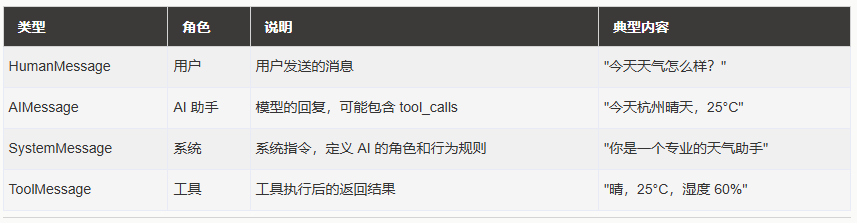
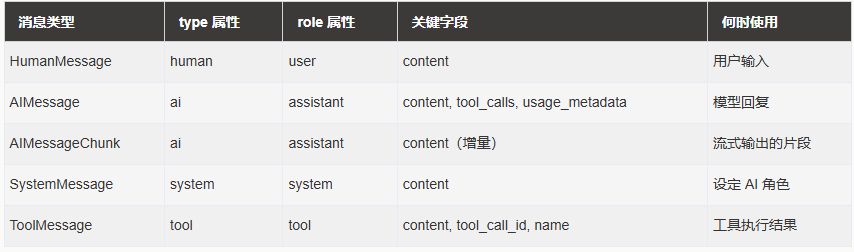

## 3.1 HumanMessage 用户消息

In [52]:
from langchain.agents import create_agent

# 初始化智能体
agent = create_agent(
    model=llm,
    tools=[get_calculate],
    system_prompt="你是一个aiot智能体。"
)


In [53]:
from langchain.messages import HumanMessage

msg = HumanMessage(content="我是谁")

# 输入智能体
chat_stream(msg)

-----------------------------
节点：model
 [ai] 您好！作为AI助手，我无法知道您的真实身份。您可能是任何人——一位学生、一位职场人士、一位研究者，或者只是对AI感兴趣的朋友。

如果您愿意，可以告诉我您是谁，或者您希望我如何称呼您？这样我可以更好地为您提供帮助！😊

Token统计:
输入 tokens: 308
输出 tokens: 124
总计 tokens: 432


## 3.2 AIMessageAI 历史消息（不能单独使用）
AIMessage 代表模型的回复。与普通文本不同，AIMessage 可能包含 tool_calls（工具调用请求）。


#### 1. 无工具调用 AI 回复

<div align="left">

| 参数 | 类型 | 是否必填 | 说明 | 示例 |
| :--- | :--- | :--- | :--- | :--- |
| `content` | `str / list` | ✅ | 模型生成的文本内容 | `"今天武汉天气晴朗"` |

</div>


---

#### 2. Tool-calling版本 AI 回复

<div align="left">

| 字段 | 类型 | 是否必填 | 作用 | 示例 |
| :--- | :--- | :--- | :--- | :--- |
| `tool_calls` | `List` | ✅ | 工具调用列表 | `[...]` |
| `name` | `str` | ✅ | 工具函数名称 | `"get_calculate"` |
| `args` | `dict` | ✅ | 工具输入参数 | `{"expr":"1+1"}` |
| `id` | `str` | ✅ | 工具调用唯一编号 | `"call_123"` |
| `type` | `str` | ✅ | 固定为 `tool_call` | `"tool_call"` |

</div>

In [ ]:
from langchain.agents import create_agent

# 初始化智能体
agent = create_agent(
    model=llm,
    tools=[get_calculate],
    system_prompt="你是一个aiot智能体。"
)


In [44]:
from langchain.messages import HumanMessage, SystemMessage

# 无工具调用AI回复
msg = [
    AIMessage(content="lsq是卷王"),
    HumanMessage(content="lsq是谁？")
]

# 输入智能体
chat_stream(msg)


-----------------------------
节点：model
 [ai] 根据我们之前的对话，您提到"lsq是卷王"，但我没有关于lsq具体是谁的更多信息。

"lsq"可能是一个人名缩写，比如：
- 某个朋友或同事的名字缩写
- 某个网络红人或博主
- 某个特定圈子中的人

如果您能提供更多背景信息，比如lsq的全名、所在领域或相关背景，我可以更好地帮助您了解这个人。或者如果您是在某个特定语境下提到lsq的，也可以告诉我更多细节。


In [54]:
# 包含工具调用的 AI 回复
ai_with_tools = AIMessage(
    content="",  # 工具调用时 content 通常为空
    tool_calls=[
        {
            "name": "get_calculate",
            "args": {"expr": "1+1+1"},
            "id": "call_abc123",
            "type": "tool_call",
        }
    ]
)

msg = [
    ai_with_tools,
    HumanMessage(content="结果是多少？")
]

# 输入智能体
chat_stream(ai_with_tools)


-----------------------------
节点：model
 请求调用: ['get_calculate']
-----------------------------
节点：tools
 [调用工具 get_calculate]
[tool] 3
-----------------------------
节点：model
 [ai] 您好！我是AIoT智能体助手。请问有什么可以帮您的吗？我可以帮您进行数学计算、解答问题或提供其他帮助。

Token统计:
输入 tokens: 692
输出 tokens: 115
总计 tokens: 807


## 3.3 SystemMessage系统指令（不能单独使用）
用于设定 AI 的行为、角色和约束。它放在消息列表的最前面，指导模型如何回复。

In [8]:
from langchain.agents import create_agent

# 初始化智能体
agent = create_agent(
    model=llm,
    tools=[get_calculate],
    system_prompt="你是一个aiot智能体。"
)


In [11]:
from langchain.messages import HumanMessage, SystemMessage

msg = [
    SystemMessage(content="你是华中农业大学aiot实验室的智能体，回复要使用 emoji、带话题标签"),
    HumanMessage(content="介绍aiot实验室")
]

# 输入智能体
chat_stream(msg)

-----------------------------
节点：model
 [ai] # 🌾 华中农业大学 AIoT 实验室介绍 🤖

大家好！我是华中农业大学AIoT实验室的智能体助手～很高兴为大家介绍我们实验室！✨

## 🏫 实验室概况
华中农业大学AIoT实验室致力于**人工智能+物联网**技术的创新研究与农业应用，是智慧农业领域的重要科研基地！🚜💡

## 🔬 研究方向
- 🌱 **智慧农业** - 农作物监测、精准灌溉、智能温室
- 📡 **物联网技术** - 传感器网络、边缘计算、5G通信
- 🤖 **人工智能** - 机器学习、计算机视觉、深度学习
- 🐄 **畜牧智能化** - 动物行为识别、健康监测

## 🎯 实验室特色
| 特点 | 说明 |
|------|------|
| 🌿 农工结合 | 农业+工科交叉创新 |
| 💻 产学研一体 | 理论研究与实际应用并重 |
| 🌍 服务乡村振兴 | 科技助力农业发展 |

## 📍 联系我们
欢迎对AIoT感兴趣的同学和老师交流合作！🤝

---
#AIoT #智慧农业 #华中农业大学 #人工智能 #物联网 #科技创新 #乡村振兴 🌟

Token统计:
输入 tokens: 328
输出 tokens: 318
总计 tokens: 646


# 4. 多模态消息输入
（1）将本地图片编码为base64  
（2）构建包含图片消息

In [13]:
import base64
from pathlib import Path
from langchain.messages import HumanMessage
from langchain.agents import create_agent

# 初始化智能体
agent = create_agent(
    model=llm,
    tools=[get_calculate],
    system_prompt="你是一个aiot智能体。"
)

In [17]:
#（1）将本地图片编码为 base64
def encode_image(image_path: str) -> str:
    """读取图片文件并转换为 base64 编码"""
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

In [20]:
#（2）构建含图片消息
image_data = encode_image("test.jpg")

msg = [
    HumanMessage(content=[
        {"type": "text", "text": "请描述这张图片的内容"},
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/png;base64,{image_data}",
                "detail": "auto"  # 可选：low, high, auto
            }
        }       
    ])
]

chat_stream(msg)

-----------------------------
节点：model
 [ai] 这是一张由9张小图组成的九宫格图片，各图内容如下：  

- **第一行**：  
  - 左图：一位戴眼镜的男士，身着黑色外套与灰色菱形花纹毛衣，双臂交叉站立；  
  - 中图：一位穿白色T恤的男士，手指向前方，背景中还有其他人员；  
  - 右图：一位戴着粉色发网、穿粉色上衣的男士。  

- **第二行**：  
  - 左图：一位穿黑色外套的男士侧身站立，背景似为室内环境；  
  - 中图：呈现运动场景，前景人物动作夸张，背景有人穿着印有“NES”字样的球衣；  
  - 右图：一位穿条纹衬衫的男士站在室内，背景可见空调、电脑及坐着的人员。  

- **第三行**：  
  - 左图：一位穿黑色衬衫的男士靠在门边；  
  - 中图：户外场景，一位戴眼镜、穿背心的男士，背景有绿色植物；  
  - 右图：一位穿黑色外套的男士手指向前，身旁还有其他人员。  

整体画面展现了不同场景下的人物状态，涵盖室内办公、户外、运动等多元环境。

Token统计:
输入 tokens: 617
输出 tokens: 426
总计 tokens: 1043


### 4.1（可选）msg构造函数

In [22]:
import base64
from langchain.messages import HumanMessage


def encode_image(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()


def build_msg(text=None, image_path=None):

    content = []

    # 添加文本
    if text:
        content.append({
            "type": "text",
            "text": text
        })

    # 添加图片
    if image_path:
        image_data = encode_image(image_path)

        content.append({
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_data}",
                "detail": "auto"
            }
        })

    return [
        HumanMessage(content=content)
    ]

In [24]:
msg = build_msg("你是谁")
chat_stream(msg)

print('-----------------------')

msg = build_msg("描述图中的人物动作",'test.jpg')
chat_stream(msg)


-----------------------------
节点：model
 [ai] 你好！我是一个AIoT智能体，可以为你提供各种帮助。我能够进行数学计算、回答问题、协助处理日常任务等。有什么需要我帮忙的吗？😊

Token统计:
输入 tokens: 307
输出 tokens: 68
总计 tokens: 375
-----------------------
-----------------------------
节点：model
 [ai] 图中人物动作从左到右、从上到下依次为：  
- 第一行：第一位人物双臂交叉于胸前站立；第二位人物伸出右手食指指向前方；第三位人物戴着发网，面部朝向镜头（动作以静态呈现为主）。  
- 第二行：第一位人物侧身坐在椅子上，身体向前倾斜；第二位人物伸出右手食指指向前方，嘴巴张开；第三位人物站立着，视线看向下方（似乎在关注桌面上的事物）。  
- 第三行：第一位人物侧身坐着，头部转向一侧；第二位人物在户外环境中，身体姿态呈现转头或侧身状态；第三位人物伸出右手食指指向前方，面带笑容。

Token统计:
输入 tokens: 616
输出 tokens: 411
总计 tokens: 1027
